# Compact Object Coalescence Rates — Figure Notebook

Plots merger rate density estimates for BH-BH, NS-BH, and NS-NS binaries  
from `Data_Mandel_and_Broekgaarden_2026/` (tidy long-format CSVs).

**Data schema** — one row per rate estimate:

| column | description |
|---|---|
| `compact_object_type` | `"BH-BH"` / `"NS-BH"` / `"NS-NS"` |
| `formation_channel` | e.g. `"isolated-binary-evolution"` |
| `study_key` | machine-readable unique key per (DCO type, study) |
| `label` | display label, e.g. `"Rodriguez et al. (2015)"` |
| `first_author`, `year`, `month`, `ads_url`, `arxiv_url`, `code` | bibliographic info |
| `plotting_style` | `"range"` / `"credible_interval"` / `"single_value"` / `"upper_limit"` / `"lower_limit"` / `"range_with_upper_limit"` / `"range_with_lower_limit"` |
| `rate_Gpc3yr` | merger rate in Gpc⁻³ yr⁻¹ |
| `rate_type` | `"lower"` / `"upper"` / `"central"` / `"single"` / empty (unnamed model value) |
| `submodel` | model variant label (e.g. `"fiducial"`); NaN if unlabelled |
| `notes` | raw notes from original data |

## 1 — Imports & matplotlib style

In [7]:
from pathlib import Path
from typing import Literal

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import rc, rcParams
from matplotlib.ticker import AutoMinorLocator

from __future__ import annotations # for python <3.10 

rc("font", family="serif", weight="bold")
rc("text", usetex=True)
rcParams["text.latex.preamble"] = r"\usepackage{amsmath}" + "\n" + r"\boldmath"
rc("axes", linewidth=2)
rcParams.update({
    "xtick.major.size": 12, "ytick.major.size": 12,
    "xtick.minor.size": 8,  "ytick.minor.size": 8,
    "font.weight": "bold",
})

FONTSIZE = 24

# path to the restructured data directory
DATA_DIR = Path("../Data_Mandel_and_Broekgaarden_2026")

# figures are saved here (created automatically if it doesn't exist)
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

## 2 — Colour palette & channel labels

In [8]:
# Formation channels in display order
ALL_CHANNELS = [
    "observations-GWs",
    "observations-sGRBs",
    "observations-kilonovae",
    "observations-pulsars",
    "isolated-binary-evolution",
    "CHE",
    "population-III",
    "flybys",
    "triples",
    "globular-clusters",
    "nuclear-clusters",
    "young-stellar-clusters",
    "primordial",
]

_palette = ["orangered"] + list(sns.color_palette("husl", len(ALL_CHANNELS) - 1))
CHANNEL_COLOR: dict[str, tuple] = dict(zip(ALL_CHANNELS, _palette))

CHANNEL_LABEL: dict[str, str] = {
    "observations-GWs":          r"Gravitational waves",
    "observations-sGRBs":        r"Short gamma-ray bursts",
    "observations-kilonovae":    r"Kilonovae",
    "observations-pulsars":      r"Galactic pulsar binaries",
    "isolated-binary-evolution": r"Isolated binary evolution",
    "CHE":                       r"Chemically homogeneous evolution",
    "population-III":            r"Population III stars",
    "flybys":                    r"Wide isolated binaries $+$ flybys",
    "triples":                   r"Triples / Multiples",
    "globular-clusters":         r"Globular clusters",
    "nuclear-clusters":          r"Nuclear star clusters",
    "young-stellar-clusters":    r"Young / Open star clusters",
    "primordial":                r"Primordial",
}

DCO_LABEL = {"BH-BH": "BH-BH", "NS-BH": "NS-BH", "NS-NS": "NS-NS"}

## 3 — Data loading

In [9]:
def load_channel(channel: str, data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Load one formation-channel CSV."""
    return pd.read_csv(
        data_dir / f"{channel}.csv",
        dtype={"year": "Int64", "month": "Int64"},
    )


def load_all(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Load and concatenate all formation-channel CSVs."""
    return pd.concat(
        [pd.read_csv(p, dtype={"year": "Int64", "month": "Int64"})
         for p in sorted(data_dir.glob("*.csv"))],
        ignore_index=True,
    )


# Quick sanity check
df_all = load_all()
print(f"Total rows: {len(df_all)}")
print(df_all.groupby(["compact_object_type", "formation_channel"]).size().to_string())

Total rows: 3863
compact_object_type  formation_channel        
BH-BH                CHE                            18
                     flybys                          2
                     globular-clusters              61
                     isolated-binary-evolution    1046
                     nuclear-clusters               77
                     observations-GWs               12
                     population-III                 13
                     primordial                      6
                     triples                        43
                     young-stellar-clusters         32
NS-BH                CHE                             2
                     flybys                          1
                     globular-clusters               9
                     isolated-binary-evolution    1001
                     nuclear-clusters               10
                     observations-GWs                9
                     observations-pulsars            1
 

## 4 — Drawing helpers

### `plotting_style` → visual encoding

| `plotting_style` | visual |
|---|---|
| `range` | horizontal bar min→max, all values as dots |
| `credible_interval` | same bar, central value marked in black |
| `single_value` | single dot |
| `upper_limit` | downward-triangle (▽) at maximum value |
| `lower_limit` | upward-triangle (△) at minimum value |
| `range_with_upper_limit` | range bar + ▽ at max |
| `range_with_lower_limit` | range bar + △ at min |

In [10]:
def _rates(group: pd.DataFrame) -> np.ndarray:
    """Sorted, non-NaN rate values for one study group."""
    return np.sort(group["rate_Gpc3yr"].dropna().to_numpy())


def draw_study(
    ax: plt.Axes,
    group: pd.DataFrame,
    y: float,
    color,
) -> None:
    """
    Draw one study (all rows sharing the same study_key + DCO type)
    at vertical position `y` on `ax`.
    """
    ps    = group["plotting_style"].iloc[0]
    rates = _rates(group)
    if len(rates) == 0:
        return

    LWIDTH = 5.5
    DOT_S  = 125
    LIM_S  = 400

    # ── Single-point styles ──────────────────────────────────────────────
    if ps == "single_value":
        ax.scatter(rates[0], y, s=DOT_S, c=[color], zorder=100, marker="o")
        return

    if ps == "upper_limit":
        ax.scatter(rates[-1], y, s=LIM_S, c="k", zorder=1e6, marker=4)   # ▽
        return

    if ps == "lower_limit":
        ax.scatter(rates[0], y, s=LIM_S, c="k", zorder=1e6, marker=5)    # △
        return

    # ── Range-based styles ───────────────────────────────────────────────
    # coloured error bar
    ax.errorbar(
        x=[rates.min(), rates.max()], y=[y, y], yerr=[0.42, 0.42],
        color=color, lw=LWIDTH, ecolor=color, zorder=5,
    )
    # black outline
    ax.errorbar(
        x=[rates.min(), rates.max()], y=[y, y], yerr=[0.42, 0.42],
        fmt="o", lw=3.5, ecolor="k", color="k", zorder=1e5,
    )
    # individual model values as dots
    ax.scatter(rates, np.full_like(rates, y), s=DOT_S, color=[color], zorder=100, marker="o")

    if ps == "range_with_upper_limit":
        ax.scatter(rates.max(), y, s=LIM_S, c="k", zorder=1e6, marker=4)
    elif ps == "range_with_lower_limit":
        ax.scatter(rates.min(), y, s=LIM_S, c="k", zorder=1e6, marker=5)
    elif ps == "credible_interval":
        central = group.loc[group["rate_type"] == "central", "rate_Gpc3yr"]
        if not central.empty:
            ax.scatter(central.iloc[0], y, s=DOT_S, c="k", zorder=1e6, marker="o")


def draw_study_label(
    ax: plt.Axes,
    group: pd.DataFrame,
    y: float,
    fontsize: float = FONTSIZE - 5,
) -> None:
    """Place the study label text left or right of the data point(s)."""
    rates = _rates(group)
    if len(rates) == 0:
        return
    label = group["label"].iloc[0]
    if rates.min() > 2e-2:
        ax.text(rates.min() / 1.25, y, label, ha="right", va="center", fontsize=fontsize)
    elif rates.max() > 1e-3:
        ax.text(rates.max() * 1.25, y, label, ha="left",  va="center", fontsize=fontsize)
    else:
        ax.text(1e-3 * 1.35,       y, label, ha="left",  va="center", fontsize=fontsize)

## 5 — Axes setup

In [11]:
def setup_axes(
    ax: plt.Axes,
    dco_type: str,
    n_rows: int,
    n_channels: int,
) -> None:
    """Apply log scale, limits, labels, and grid lines to `ax`."""
    xmin, xmax = 1e-3, 1e5
    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-(n_rows + 2 * n_channels) - 0.5, 0.5)
    ax.set_yticks([])

    dco_str = DCO_LABEL[dco_type].replace("-", r"\text{-}")
    xlabel = (
        r"$\mathrm{Local}\ \mathbf{" + dco_str
        + r"}\ \mathbf{merger\ rate\ density}\ [\mathrm{Gpc}^{-3}\ \mathrm{yr}^{-1}]$"
    )
    ax.set_xlabel(xlabel, fontsize=FONTSIZE + 6, labelpad=4)

    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(FONTSIZE)
    ax.tick_params(which="major", length=10, width=1.5)
    ax.tick_params(which="minor", length=5,  width=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    # mirrored x-axis label on top
    ax2 = ax.twiny()
    ax2.set_xscale("log")
    ax2.set_xlim(xmin, xmax)
    ax2.set_xlabel(xlabel, fontsize=FONTSIZE + 6, labelpad=20)
    for tick in ax2.xaxis.get_major_ticks():
        tick.label2.set_fontsize(FONTSIZE)
    ax2.tick_params(which="major", length=10, width=1.5)

    for xv in [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4, 1e5]:
        ax.axvline(xv, lw=1.5, color="gray", ls=":", zorder=0)

## 6 — Main figure function

In [12]:
def make_figure(
    dco_type: Literal["BH-BH", "NS-BH", "NS-NS"],
    channels: list[str],
    data_dir: Path = DATA_DIR,
    order: Literal["year", "max_rate"] = "year",
    fig_width: float = 20,
    save_path: str | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Build a horizontal merger-rate-density figure for `dco_type`.

    Parameters
    ----------
    dco_type   : "BH-BH", "NS-BH", or "NS-NS"
    channels   : formation channels to include, in the desired display order
    data_dir   : path to Data_Mandel_and_Broekgaarden_2026/
    order      : sort studies within each channel by "year" or "max_rate"
    fig_width  : figure width in inches
    save_path  : if given, save as <save_path>.png and <save_path>.pdf
    """
    # ── Load & filter data ───────────────────────────────────────────────
    frames = []
    for ch in channels:
        try:
            df_ch = load_channel(ch, data_dir)
        except FileNotFoundError:
            print(f"WARNING: {ch}.csv not found — skipping.")
            continue
        frames.append(df_ch[df_ch["compact_object_type"] == dco_type])

    if not frames:
        raise ValueError("No data found for the requested channels / DCO type.")
    df = pd.concat(frames, ignore_index=True)

    # ── Compute y positions ──────────────────────────────────────────────
    y_pos: dict[tuple[str, str], float] = {}   # (channel, study_key) → y
    channel_label_y: dict[str, float] = {}     # channel → y for channel label
    separator_ys: list[float] = []

    y = 0.0
    total_studies = 0
    for i_ch, ch in enumerate(channels):
        ch_df = df[df["formation_channel"] == ch]
        if ch_df.empty:
            continue

        y -= 1.0  # blank row above each channel block

        # Ordered list of study_keys for this channel
        if order == "max_rate":
            max_rates = (
                ch_df.groupby("study_key")["rate_Gpc3yr"].max()
                .sort_values()
            )
            sorted_keys = max_rates.index.tolist()
        else:  # year
            sorted_keys = (
                ch_df.drop_duplicates("study_key")
                .sort_values(["year", "study_key"])["study_key"]
                .tolist()
            )

        channel_label_y[ch] = y - (len(sorted_keys) - 1) / 2

        for sk in sorted_keys:
            y_pos[(ch, sk)] = y
            y -= 1.0
            total_studies += 1

        y -= 1.0  # blank row below each channel block
        if i_ch < len(channels) - 1:
            separator_ys.append(y + 0.5)

    # ── Create figure ────────────────────────────────────────────────────
    fig_height = max(6, total_studies * 0.28 + 2 * len(channels) * 0.28 + 2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    setup_axes(ax, dco_type, total_studies, len(channels))

    # Dotted channel separators
    for sy in separator_ys:
        ax.plot([1e-3, 1e5], [sy, sy], lw=1.5, c="gray", ls=":", zorder=0)

    # ── Plot each study ──────────────────────────────────────────────────
    for ch in channels:
        ch_df = df[df["formation_channel"] == ch]
        color = CHANNEL_COLOR.get(ch, "gray")

        for sk, group in ch_df.groupby("study_key", sort=False):
            key = (ch, sk)
            if key not in y_pos:
                continue
            yv = y_pos[key]
            draw_study(ax, group, yv, color)
            draw_study_label(ax, group, yv)

        # Channel group label (right-aligned)
        if ch in channel_label_y:
            ax.text(
                9e4, channel_label_y[ch],
                r"\textbf{%s}" % CHANNEL_LABEL.get(ch, ch),
                ha="right", va="center",
                fontsize=FONTSIZE + 8, color=color, weight="bold",
            )

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)

    if save_path is not None:
        sp = Path(save_path)
        plt.savefig(sp.with_suffix(".png"), dpi=300, transparent=False)
        plt.savefig(sp.with_suffix(".pdf"))
        print(f"Saved {sp.with_suffix('.png')} and {sp.with_suffix('.pdf')}")

    return fig, ax

## 7 — BH-BH figure

Saved ../figures/Rates_BHBH_yearsorted.png and ../figures/Rates_BHBH_yearsorted.pdf


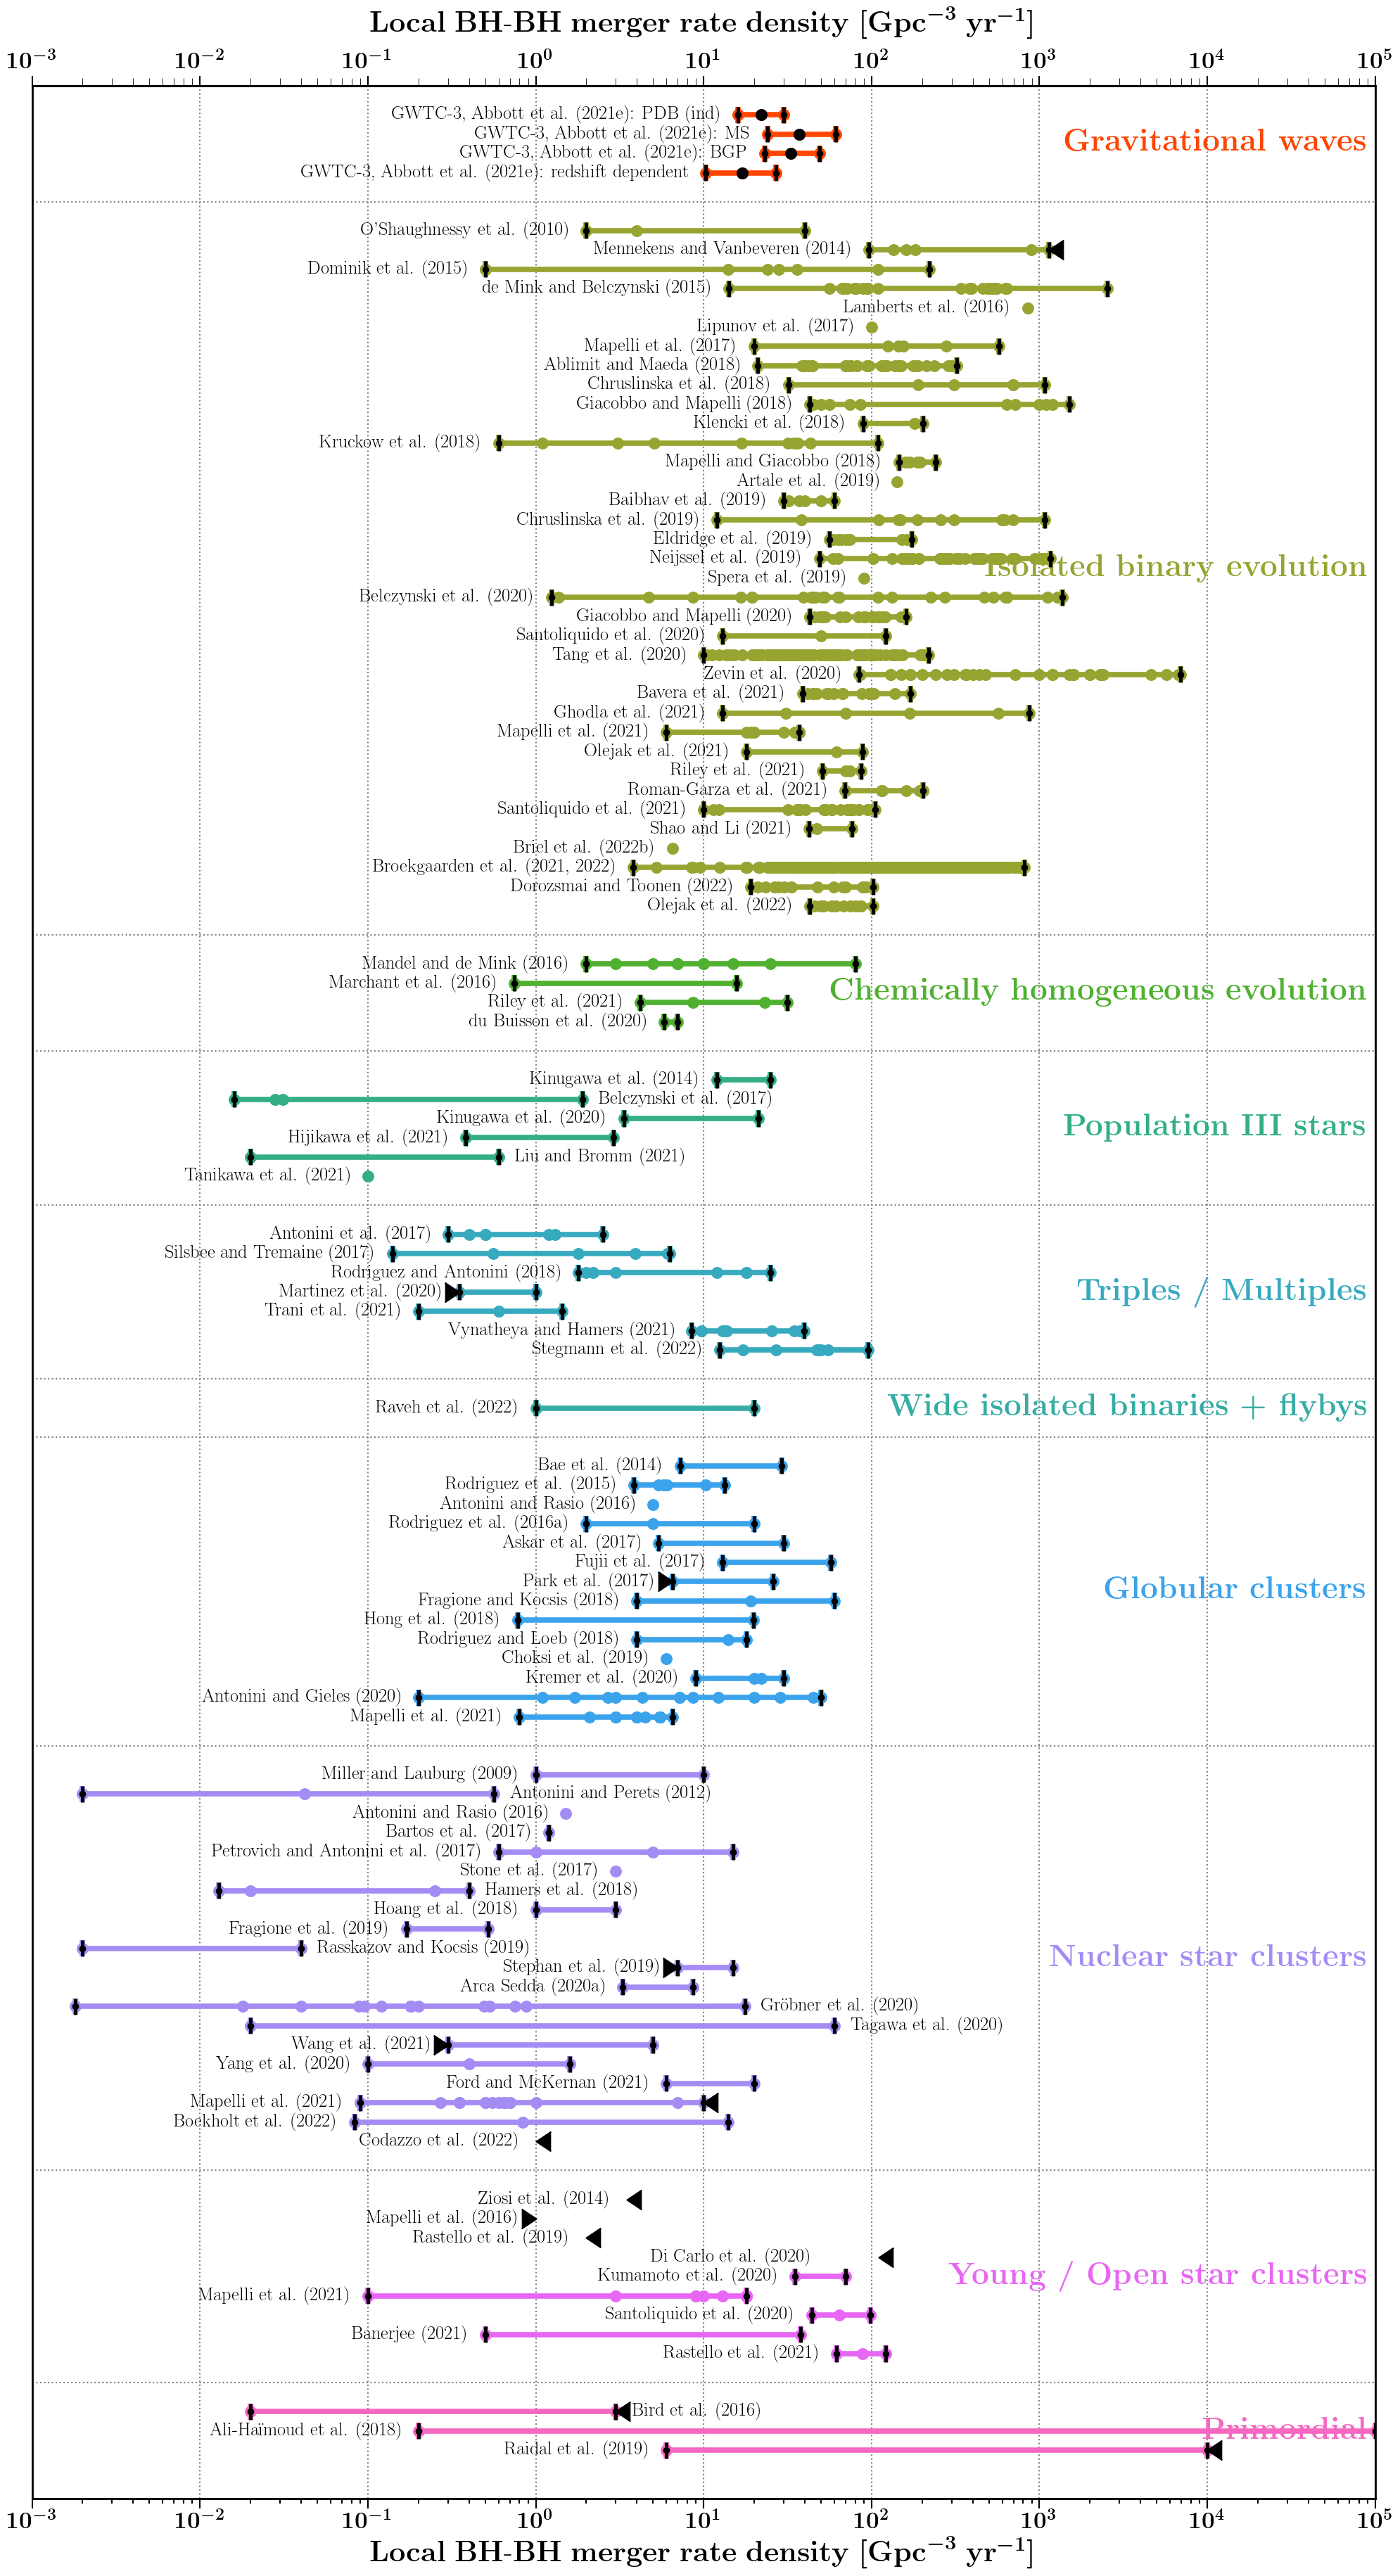

In [13]:
CHANNELS_BHBH = [
    "observations-GWs",
    "isolated-binary-evolution",
    "CHE",
    "population-III",
    "triples",
    "flybys",
    "globular-clusters",
    "nuclear-clusters",
    "young-stellar-clusters",
    "primordial",
]

fig_bhbh, ax_bhbh = make_figure(
    dco_type="BH-BH",
    channels=CHANNELS_BHBH,
    order="year",
    save_path=FIGURES_DIR / "Rates_BHBH_yearsorted",
)
plt.show()

## 8 — NS-BH figure

Saved ../figures/Rates_NSBH_yearsorted.png and ../figures/Rates_NSBH_yearsorted.pdf


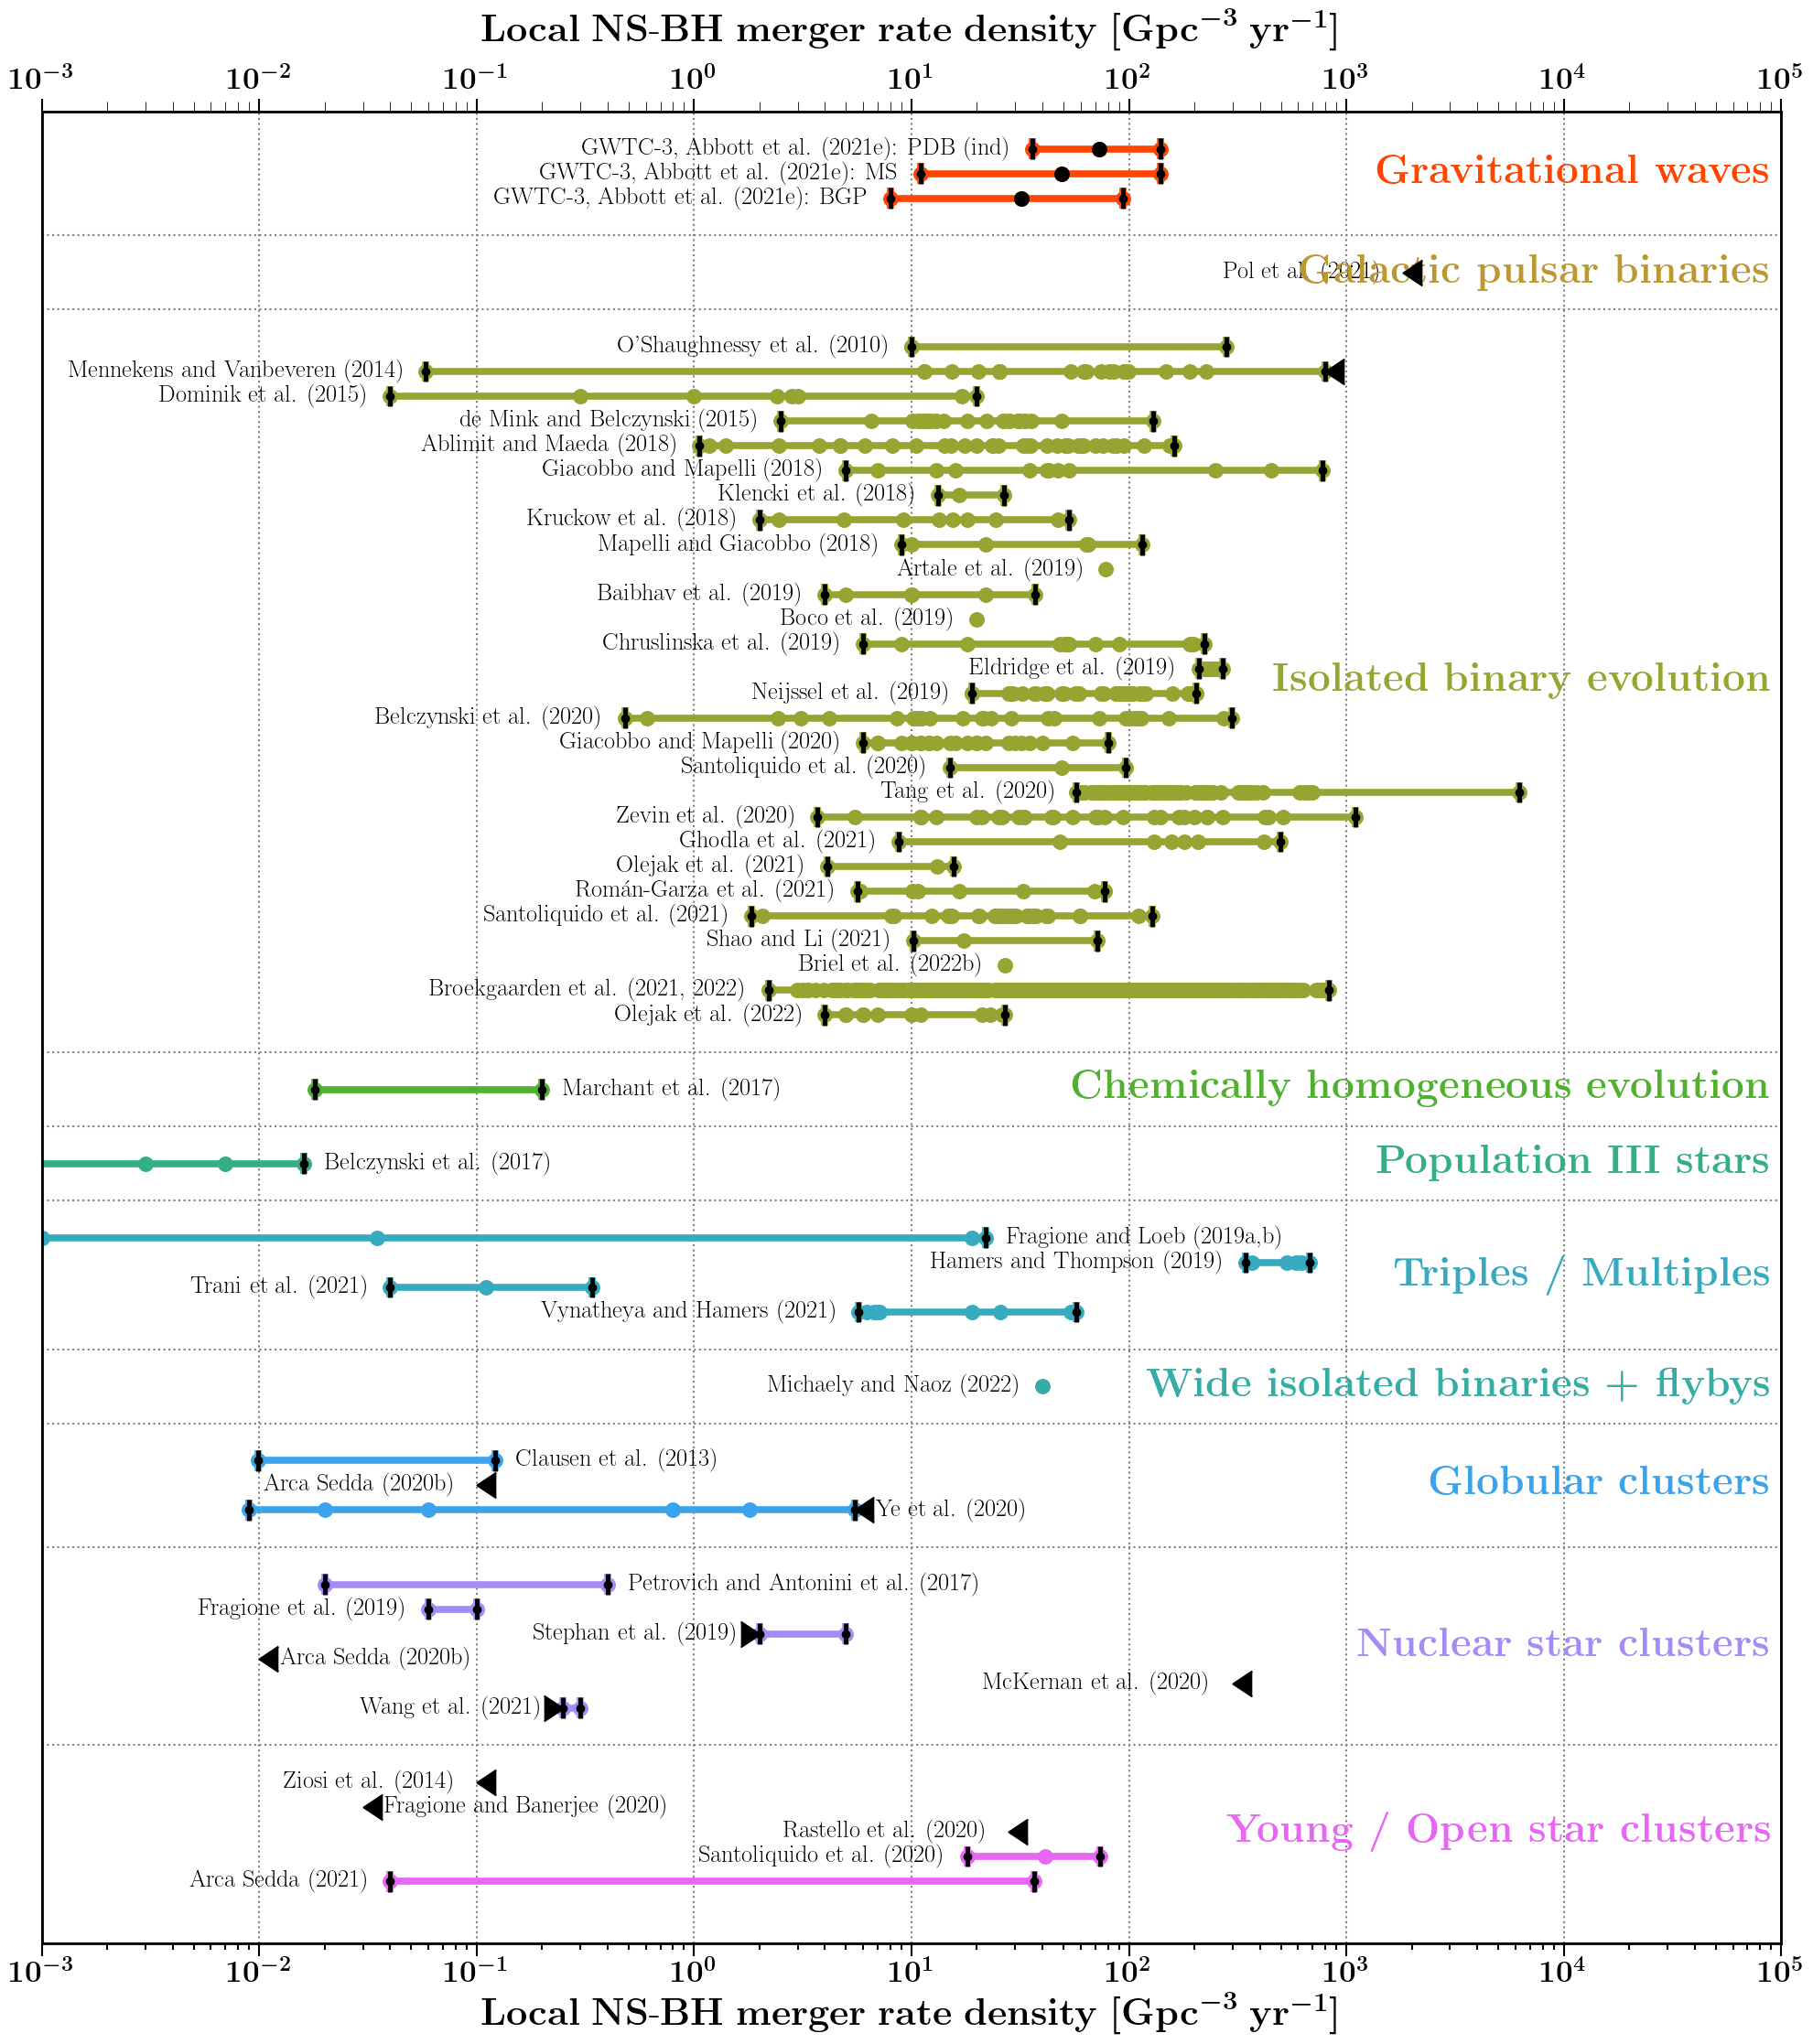

In [14]:
CHANNELS_NSBH = [
    "observations-GWs",
    "observations-pulsars",
    "isolated-binary-evolution",
    "CHE",
    "population-III",
    "triples",
    "flybys",
    "globular-clusters",
    "nuclear-clusters",
    "young-stellar-clusters",
]

fig_nsbh, ax_nsbh = make_figure(
    dco_type="NS-BH",
    channels=CHANNELS_NSBH,
    order="year",
    save_path=FIGURES_DIR / "Rates_NSBH_yearsorted",
)
plt.show()

## 9 — NS-NS figure

Saved ../figures/Rates_NSNS_yearsorted.png and ../figures/Rates_NSNS_yearsorted.pdf


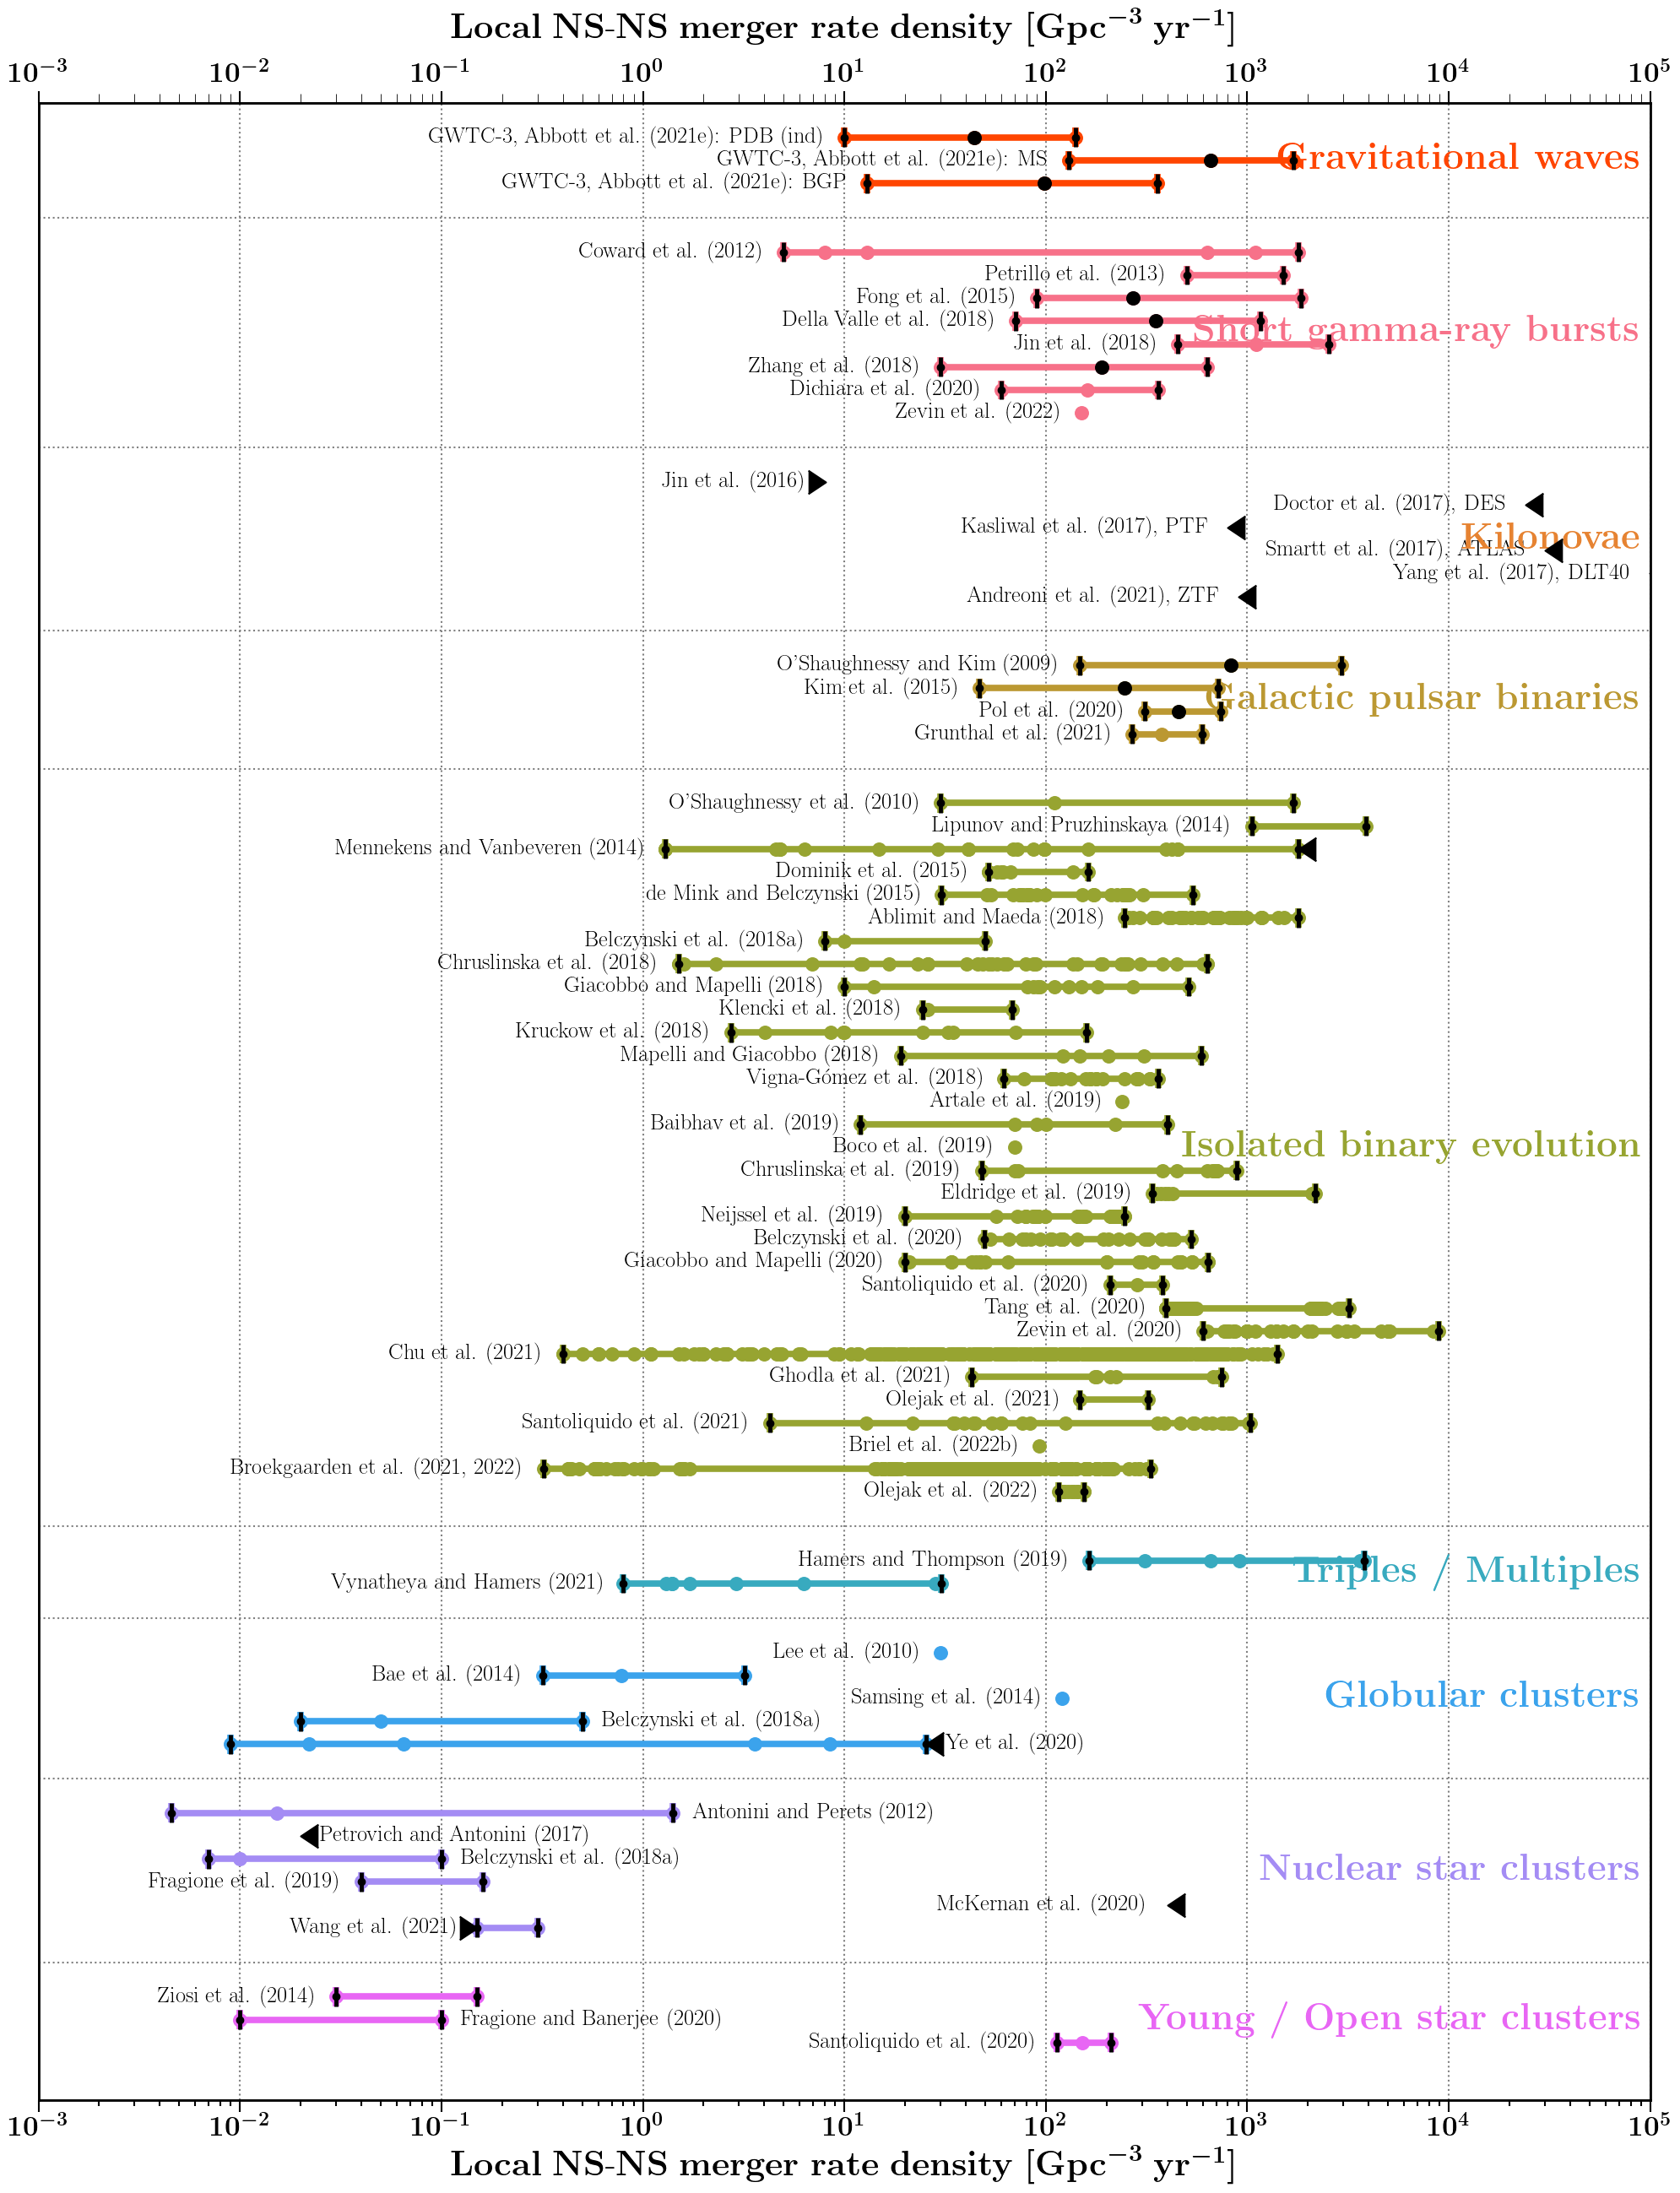

In [15]:
CHANNELS_NSNS = [
    "observations-GWs",
    "observations-sGRBs",
    "observations-kilonovae",
    "observations-pulsars",
    "isolated-binary-evolution",
    "triples",
    "globular-clusters",
    "nuclear-clusters",
    "young-stellar-clusters",
]

fig_nsns, ax_nsns = make_figure(
    dco_type="NS-NS",
    channels=CHANNELS_NSNS,
    order="year",
    save_path=FIGURES_DIR / "Rates_NSNS_yearsorted",
)
plt.show()